[HybridVideoMAE](https://github.com/OpenGVLab/VideoMAEv2/blob/master/dataset/pretrain_datasets.py#L268)

In [1]:
%matplotlib inline

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE" # tells OpenMP to not complain if it notices that two copies of OpenMP are loaded.

from IPython.display import Video
from IPython.display import Audio as play_audio
from torchvision.utils import make_grid
from torchcodec.encoders import VideoEncoder

def play_video(encoded_bytes):
    return Video(data=encoded_bytes.numpy().tobytes(),
                embed=True, width=640, height=360, mimetype="video/mp4")

import matplotlib.pyplot as plt

import sys
sys.path.append('../../../')

In [8]:
from pathlib import Path

import torch
import numpy as np
from PIL import Image

%load_ext autoreload
%autoreload 2
    
from computer_vision.video_mae.parameter_parser import parser
from computer_vision.video_mae.dataset.pretrained_datasets import HybridVideoMAE
from computer_vision.video_mae.models.modeling_pretrain import pretrain_videomae_large_patch16_224

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
data_dirpath=Path('D:/data/UCF101')
root=data_dirpath/'UCF-101'
annotation_path=data_dirpath/'UCF101TrainTestSplits-RecognitionTask/trainlist01.txt'
metadata_path=data_dirpath/'metadata_framerate4.pt'

mini_train=False
if not mini_train:
    output_dirpath=Path('D:/results/ucf101/video_mae/train') 
    arguments= f"""--data_root {root} --data_path {annotation_path} 
    """ # --use-cutmix-mixup
else:
    output_dirpath=Path('D:/results/ucf101/video_mae/mini_train') 
    arguments= f"""--data_root {root} --data_path {annotation_path} 
    """ # --use-cutmix-mixup --time 18
args=parser.parse_args(arguments.split())
args.num_frames, args.sampling_rate, args.mask_type, args.decoder_mask_ratio, args.decoder_mask_type, args.model

(16, 4, 'tube', 0.5, 'run_cell', 'pretrain_videomae_base_patch16_224')

In [9]:
model = pretrain_videomae_large_patch16_224() 

In [14]:
print(f'{model.encoder.patch_embed.patch_size=}, {args.tubelet_size=}')
patch_size=model.encoder.patch_embed.patch_size
args.window_size=(args.num_frames//args.tubelet_size,
                  args.input_size//patch_size[0],
                  args.input_size//patch_size[1])
args.patch_size=patch_size
print(f'{args.window_size=}, {args.mask_ratio=}')

model.encoder.patch_embed.patch_size=(16, 16), args.tubelet_size=2
args.window_size=(8, 14, 14), args.mask_ratio=0.9


In [4]:
dataset=HybridVideoMAE(root=args.data_root, setting=args.data_path, train=True, test_mode=False, name_pattern=args.fname_tmpl, 
                       video_ext='avi', is_color=True, modality='rgb', num_segments=1, num_crop=1, new_length=args.num_frames, 
                       new_step=args.sampling_rate, transform=None, temporal_jitter=False, lazy_init=False, num_sample=args.num_sample)

In [33]:
index=890
# def __getitem__(self, index):
try:
    video_name, label=dataset.clips[index]
    dataset.skip_length=dataset.orig_skip_length
    dataset.new_step=dataset.orig_new_step
    
    decord_vr=dataset.video_loader(video_name)
    duration=len(decord_vr) #number of total frames
    print(f"{duration=}")
    segment_indices,skip_offsets=dataset._sample_train_indices(duration)
    frame_id_list=dataset.get_frame_id_list(duration, segment_indices, skip_offsets)
    video_data=decord_vr.get_batch(frame_id_list).asnumpy() # (num_frames, H, W, C) where C is the number of channels
    images=[Image.fromarray(video_data[vid,]) for vid in range(len(frame_id_list))] # convert each frame to PIL.Image
except Exception as e:
    print(f"Failed to load video from {video_name} with error {e}")
    index=np.random.randint(0, len(dataset.clips))
    # return dataset.__getitem__(index)

# if dataset.num_sample>1: # get multiple augmented clips from the same extracted video clip
#     process_data_list, encoder_mask_list, decoder_mask_list=[],[],[]
#     for _ in range(dataset.num_sample):
#         process_data, encoder_mask, decoder_mask=dataset.transform((images, None))
#         process_data=process_data.view((dataset.new_length, 3)+process_data.size()[-2:]).transpose(0,1) # (T,C,H,W)->(C,T,H,W)
#         process_data_list.append(process_data)
#         encoder_mask_list.append(encoder_mask)
#         decoder_mask_list.append(decoder_mask)
#     return process_data_list, encoder_mask_list, decoder_mask_list
# else:
#     process_data, encoder_mask, decoder_mask=dataset.transform((images, None))
#     # (T*C,H,W)->(T,C,H,W)->(C,T,H,W)
#     process_data=process_data.view((dataset.new_length,3)+process_data.size()[-2:]).transpose(0,1)
#     return process_data, encoder_mask, decoder_mask
    

duration=134


In [46]:
output_dirpath=Path('D:/results/ucf101/video_mae')
output_dirpath.mkdir(parents=True, exist_ok=True)
torch.save(video_data, output_dirpath/'extracted_video_data_numpy.pt')

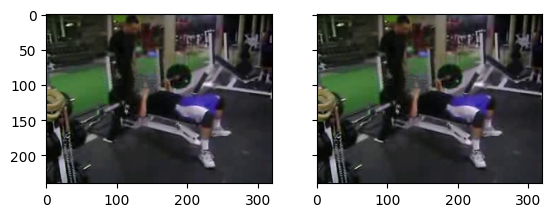

In [26]:
fig, ax=plt.subplots(1, 2, sharex=True, sharey=True)
ax[0].imshow(x)
ax[1].imshow(x.convert('RGB'))

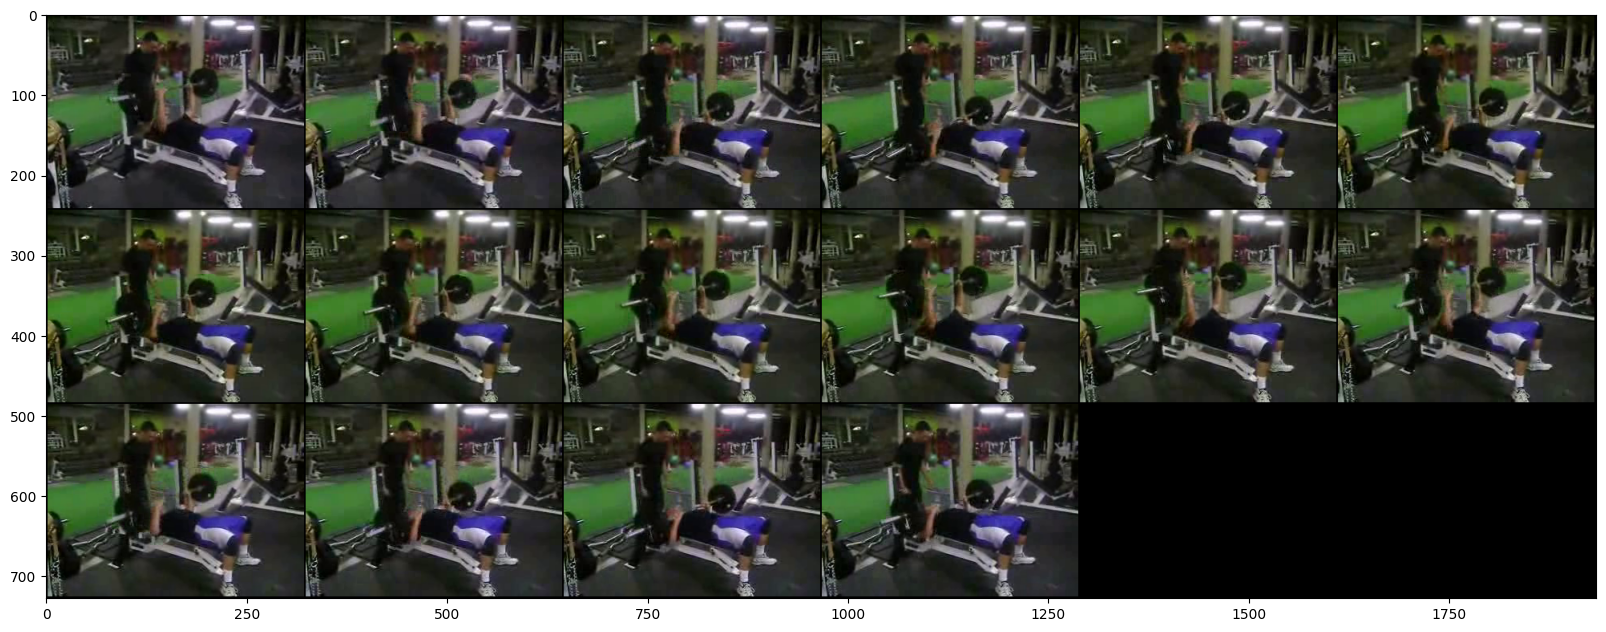

In [43]:
fig, ax=plt.subplots(figsize=(20,18))
ax.imshow(make_grid(torch.from_numpy(video_data).permute(0,3,1,2), nrow=6).permute(1,2,0))